In [1]:
from sbi_particle_physics.config import REAL_DATA, C9, DEFAULT_STRIDE, DEFAULT_PRERUNS, DEFAULT_PRE_N
from sbi_particle_physics.managers.real_data import RealData
from sbi_particle_physics.managers.plotter import Plotter
import torch
from sbi_particle_physics.objects.model import Model

In [2]:
device = "cpu"
n_points = 3000
raw_data = RealData.load_one_file(REAL_DATA / "dataset_bin_8_job_0_0.root", device=device)
print(raw_data[0])
print(raw_data.shape)

tensor([ 2.2665,  0.1136, -0.5955,  2.4328,  5.2816])
torch.Size([5041, 5])


In [3]:
raw_data = RealData.load_whole_directory(REAL_DATA, device)[:n_points]
print(raw_data.shape)

Loading LHCb files:   0%|          | 0/40 [00:00<?, ?it/s]

torch.Size([3000, 5])


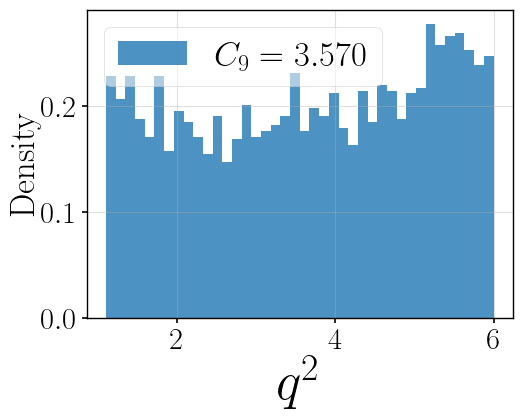

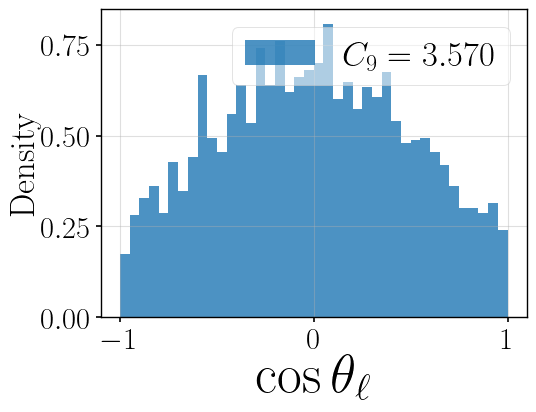

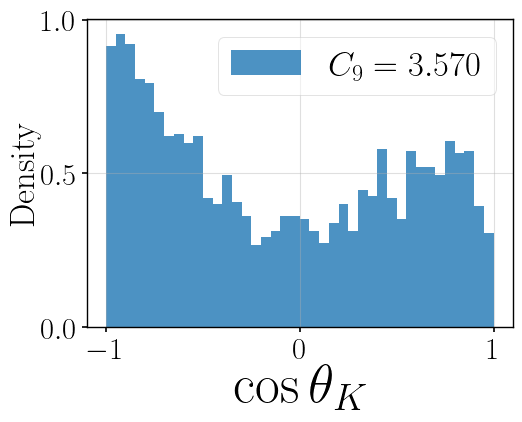

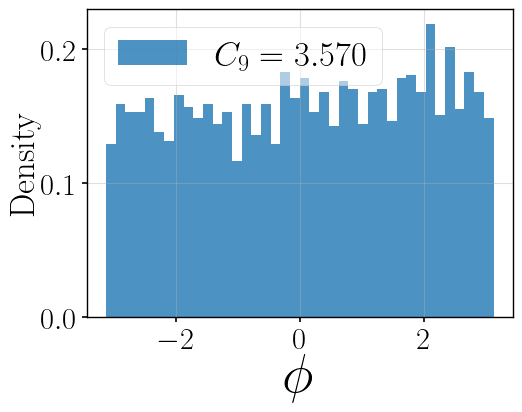

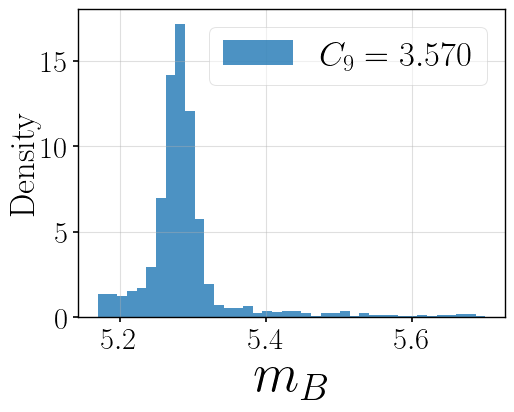

In [4]:
Plotter.plot_a_sample(raw_data, torch.as_tensor(C9, device=device))

In [5]:
model = Model(device, n_points=n_points)

model.set_prior_basic([3], [5])
model.set_simulator(stride=DEFAULT_STRIDE, pre_N=DEFAULT_PRE_N, preruns=DEFAULT_PRERUNS)
model.set_normalizer_with_data(raw_data=raw_data)
model.build_default()
data = model.normalizer.normalize_data(raw_data)

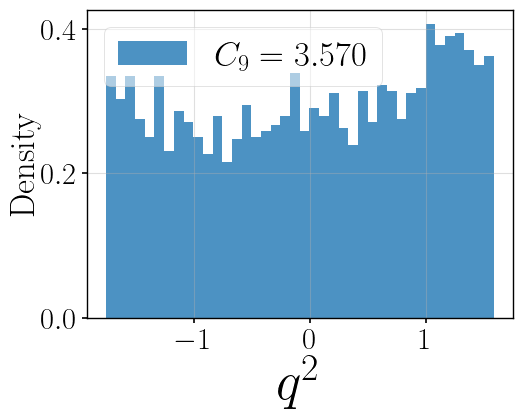

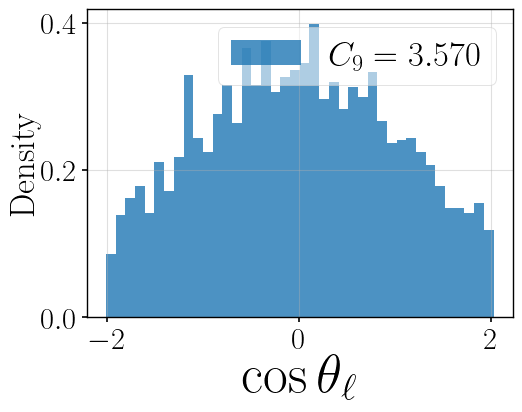

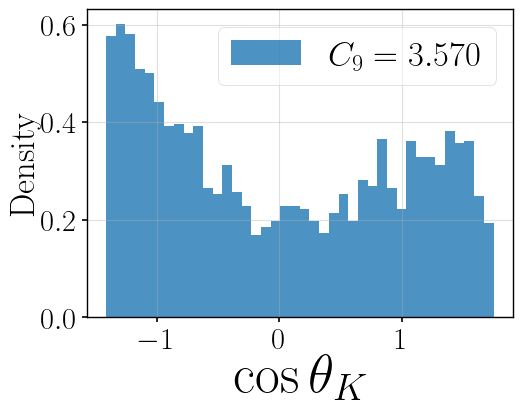

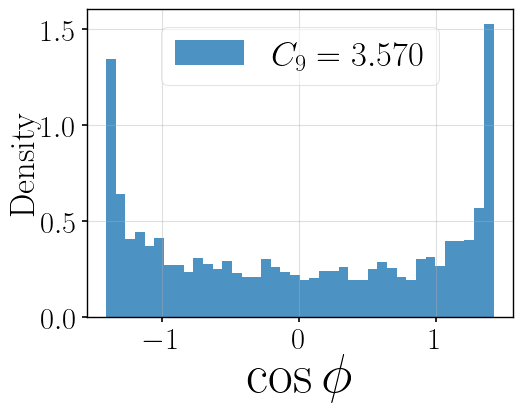

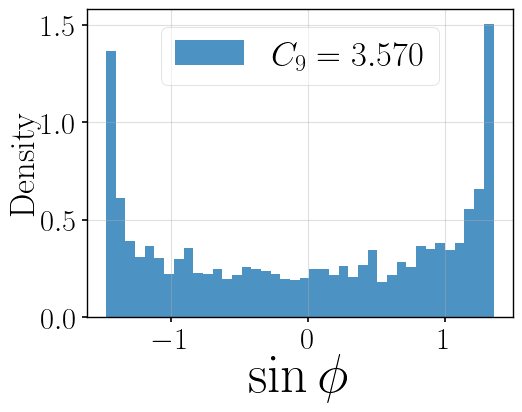

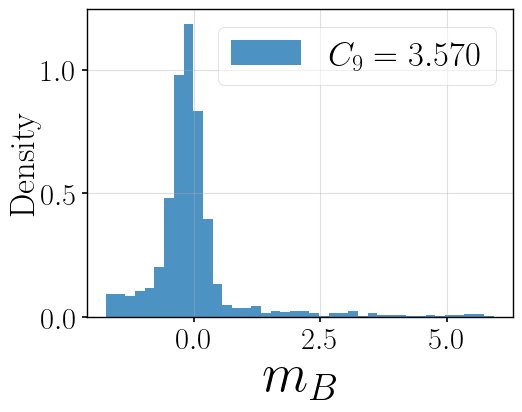

In [6]:
Plotter.plot_a_sample(data, torch.as_tensor(C9, device=device), raw=False)
 # phi is cos phi, because this function is supposed to be called with raw data

In [7]:
print(data.shape)
print(raw_data.shape)
print(data[:,5].mean(), data[:,5].std())
print(raw_data[:,4].mean(), raw_data[:,4].std())
print(model.normalizer.data_mean, model.normalizer.data_std)

torch.Size([3000, 6])
torch.Size([3000, 5])
tensor(2.8140e-06) tensor(1.0002)
tensor(5.2907) tensor(0.0690)
tensor([ 3.6767e+00, -4.0171e-03, -1.0571e-01, -4.4965e-03,  4.0015e-02,
         5.2907e+00]) tensor([1.4640, 0.4935, 0.6306, 0.7057, 0.7073, 0.0690])


In [8]:
raw_data = RealData.load_n_points(REAL_DATA, n_points, device=device, ignore_first=n_points+5)

Loading LHCb data (partial):   0%|          | 0/40 [00:00<?, ?it/s]

In [9]:
print(raw_data.shape)
print(raw_data[0])

torch.Size([3000, 5])
tensor([ 5.4227e+00,  7.5624e-01, -6.9466e-01, -4.5393e-01,  5.2806e+03])
